# Germany smoke test — SIMPLACE vs torchcrop vs observations

~30 cropland cells across Germany, each in a distinct CyBench NUTS-3 region,
run by **both models over the same cells**, each swept over the same three
`vIOPT`/`iopt` settings (1 potential, 2 water-limited, 3 water+N — 4 is
dropped, since no European soil P or K layer exists). Every figure below
therefore carries six series, and a same-IOPT pair (`simplace_iopt<n>` vs
`torchcrop_iopt<n>`) differs only in the model. Colour alone does not stay
legible at six overlapping lines, so every plot also varies marker and
linestyle by series — the same combination in every figure, so a series is
identifiable without re-reading each legend.

Two references, and they are not the same kind of thing:

* **CyBench** — an administrative yield statistic over a whole NUTS-3 region,
  at market moisture (~13.5 %). A simulated cell is one point inside it, and
  the models report grain **dry matter**, so ~15 % of the reference is water
  that no correction is applied for here.
* **PEP725** — BBCH stage dates observed by volunteers at a station, matched to
  the nearest simulated cell within 25 km.

Neither pairing is exact, and the spread that comes from the mismatch is not
model error. Produce the inputs with:

```bash
./submit/submit_cropmodelling.sh --smoke
```

which, once per swept IOPT (`TC_SMOKE_IOPTS`, default `1 2 3`), builds and
runs its own SIMPLACE solution — there is no CLI override for `vIOPT` the way
torchcrop has `--iopt`, so unlike torchcrop this is a separate build per
value — hands its simulated sowing dates to torchcrop at that same IOPT, and
prepares `torchcrop/workspace/crop_wheat.yaml` — the crop parameters torchcrop
actually ran, checkable directly against the SIMPLACE template's
`data/crop/crop.xml`, `data/crop/seeds.xml` and `data/management/management.xml`
(`torchcrop/workspace/crop_parameter_audit.csv` does that comparison already,
parameter by parameter).

In [14]:
import logging
import sys
from pathlib import Path

# cropmodelling4eu is installed (pip install -e .), so the evaluation
# library is imported like any other package rather than off sys.path.

import numpy as np
import pandas as pd

from cropmodelling4eu.evaluation import aggregate, config, cybench, doy, metrics, plots, regions, torchcrop
from cropmodelling4eu.evaluation.style import use_style

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s",
                    force=True)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

PALETTE = use_style("light")
config.ensure_output_dirs()

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 140)

print(f"TorchCrop run : {config.TORCHCROP_RUN_DIR}")
print(f"CyBench root  : {config.CYBENCH_ROOT}")
print(f"Outputs       : {config.OUTPUT_DIR}")

TorchCrop run : /data01/FDS/muduchuru/Data/SIMPLACE/torchcrop/winter_wheat_2000_2024
CyBench root  : /data01/FDS/muduchuru/Data/Agri/cybench
Outputs       : /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs


In [36]:
from cropmodelling4eu.evaluation import germany

SMOKE = Path("/data01/FDS/muduchuru/Data/SIMPLACE/cropmodelling4eu/de_smoke")

# Both models sweep all three usable IOPT settings over the same cells and
# seasons -- submit_cropmodelling.sh --smoke builds one SIMPLACE run
# (simplace_iopt<n>/) and one torchcrop run (de_torchcrop_iopt<n>.parquet)
# per value. A same-IOPT pair then differs only in the model, and the spread
# across IOPT on one side is the nutrient-limitation effect on its own, not a
# confound with the model.
IOPTS = [1]

cells = pd.read_csv(SMOKE / "de_cells.csv")
runs = germany.load_runs(
    **{f"simplace_iopt{i}": SMOKE / f"simplace_iopt{i}" / "simplace_europe.parquet"
       for i in IOPTS},
    **{f"torchcrop_iopt{i}": SMOKE / "torchcrop" / f"de_torchcrop_iopt{i}.parquet"
       for i in IOPTS},
)
lo, hi = germany.common_window(runs)
runs = {name: f[f["year"].between(lo, hi)] for name, f in runs.items()}

print(f"{len(cells)} cells, {cells['adm_id'].nunique()} NUTS-3 regions, "
      f"{cells['lon'].min():.2f}-{cells['lon'].max():.2f} E, "
      f"{cells['lat'].min():.2f}-{cells['lat'].max():.2f} N")
print(f"common window: {lo}-{hi}")
for name, frame in runs.items():
    print(f"  {name:16s} {len(frame):5d} rows, {frame['SimplaceID'].nunique()} cells")

30 cells, 30 NUTS-3 regions, 7.15-13.55 E, 48.35-53.95 N
common window: 1989-2024
  simplace_iopt1    1078 rows, 30 cells
  torchcrop_iopt1   1078 rows, 30 cells


## 0. What torchcrop actually ran

`torchcrop/workspace/` is written by `submit_cropmodelling.sh --smoke` before
either model runs. `crop_<crop>.yaml` is not a description of the run's crop
parameters, it is the file torchcrop loaded them from
(`CropParameters(config_file=...)`) — open it beside the SIMPLACE template's
`data/crop/crop.xml`, `data/crop/seeds.xml` and `data/management/management.xml`
for the same comparison this cell prints.

In [37]:
audit = pd.read_csv(SMOKE / "torchcrop" / "workspace" / "crop_parameter_audit.csv")
print(audit["status"].value_counts().to_string())
display(audit[audit["status"] != "same"])

status
same             60
differs          15
simplace_only     2


,parameter,kind,simplace,torchcrop,status
4,TSUM1 / tsum1,scalar,1623.0,1050.0,differs
5,TSUM2 / tsum2,scalar,1020.0,1000.0,differs
7,TDWI / tdwi,scalar,15.0,21.0,differs
8,RGRLAI / rgrl,scalar,0.018,0.00817,differs
11,SPA / spa,scalar,0.0,NaN,simplace_only
22,RDMCR / rdmcr,scalar,1.0,1.25,differs
25,DEPNR / depnr,scalar,3.5,4.5,differs
52,NMAXSO / nmaxso,scalar,0.025,0.0176,differs
58,dtsmtb,table,"[[-5.0, 0.0], [0.0, 0.0], [30.0, 27.0], [45.0,...","[[-5.0, 0.0], [0.0, 0.0], [30.0, 30.0], [45.0,...",differs
59,phottb,table,"[[0.0, 0.0], [8.0, 1.0], [12.0, 1.0], [18.0, 1...","[[0.0, 0.0], [8.0, 1.0], [10.0, 1.0], [12.0, 1...",differs


## 1. Where the cells are

One cell per region, chosen nearest the centre of a 2-D lon/lat bin. Binning in
**two** dimensions matters: `SimplaceID` runs west-to-east within a row, so
taking the first cell of each latitude band walks the western border and
samples a climate gradient rather than the country.

In [38]:
fig, ax = germany.plot_cells(cells, palette=PALETTE)
fig.savefig(config.FIGURE_DIR / "de_smoke_cells.png", dpi=150, bbox_inches="tight")

## 2. Yield vs CyBench

Paired on `(NUTS-3 region, harvest year)`. Bias is `simulated − observed`, so a
negative bias is an under-prediction — and remember ~15 % of the reference is
moisture the models do not report.

In [39]:
yields = germany.validate_yield(runs, cells)
display(yields[["model", "n", "regions", "years", "sim_mean", "obs_mean",
                "bias", "rmse", "mae", "r"]].round(2))
yields.to_csv(config.TABLE_DIR / "de_smoke_yield_vs_cybench.csv", index=False)

,model,n,regions,years,sim_mean,obs_mean,bias,rmse,mae,r
0,simplace_iopt1,978.0,30,1989-2021,8.79,7.05,1.75,2.19,1.84,0.07
1,torchcrop_iopt1,978.0,30,1989-2021,8.82,7.05,1.77,2.18,1.85,0.19


In [40]:
fig, axes = germany.plot_yield(runs, cells, palette=PALETTE)
fig.savefig(config.FIGURE_DIR / "de_smoke_yield.png", dpi=300, bbox_inches="tight")

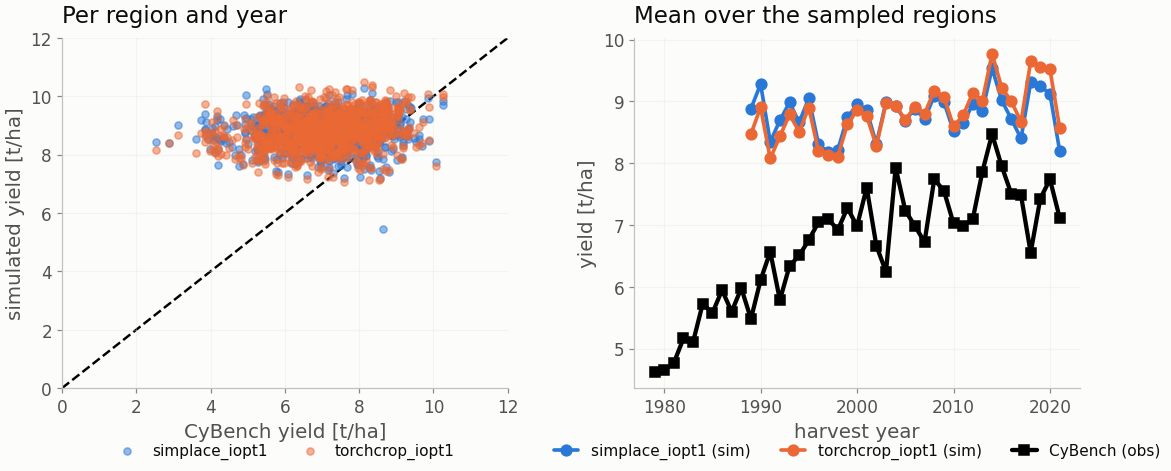

In [41]:
display(fig)

## 3. Phenology vs PEP725

One observed date per `(cell, year)`: the median over the stations matched to
that cell, which is robust to a single mis-typed entry.

**Three rows are not model error and must not be read as such:**

* **Sowing is a constant input** in both runs, so its "bias" is one continental
  offset with no degrees of freedom — `r` is undefined because a constant has
  no variance. It still matters, because it propagates into every later stage.
* **Soft dough (BBCH 85) precedes full ripeness (BBCH 89)**, which is what the
  models report as maturity, so a positive bias of a couple of weeks is the
  expected sign.
* **Emergence** depends on the solution's `vTSUMEM`, not on the export.

Heading and harvest are the genuine tests: neither is an input.

In [33]:
observed = germany.load_pep725(cells, (lo, hi))
phenology = germany.validate_phenology(runs, observed)
display(phenology[["stage", "model", "n", "sim_mean", "obs_mean",
                   "bias", "rmse", "mae", "r"]].round(1))
phenology.to_csv(config.TABLE_DIR / "de_smoke_phenology_vs_pep725.csv", index=False)

for stage, caveat in phenology[["stage", "caveat"]].drop_duplicates().values:
    print(f"  {stage:24s} {caveat}")

INFO cropmodelling4eu.evaluation.germany: PEP725: 415 stations within 25 km of a simulated cell (of 2993)


,stage,model,n,sim_mean,obs_mean,bias,rmse,mae,r
0,Sowing (BBCH 00),simplace_iopt1,991.0,273.4,280.3,-6.9,11.9,10.0,-0.1
1,Sowing (BBCH 00),simplace_iopt2,991.0,273.4,280.3,-6.9,11.9,10.0,-0.1
2,Sowing (BBCH 00),simplace_iopt3,991.0,273.4,280.3,-6.9,11.9,10.0,-0.1
3,Sowing (BBCH 00),torchcrop_iopt1,991.0,274.4,280.3,-5.9,11.4,9.5,-0.1
4,Sowing (BBCH 00),torchcrop_iopt2,991.0,274.4,280.3,-5.9,11.4,9.5,-0.1
5,Sowing (BBCH 00),torchcrop_iopt3,991.0,274.4,280.3,-5.9,11.4,9.5,-0.1
6,Emergence (BBCH 10),simplace_iopt1,987.0,279.1,294.0,-15.0,18.6,16.2,-0.1
7,Emergence (BBCH 10),simplace_iopt2,987.0,279.1,294.0,-15.0,18.6,16.2,-0.1
8,Emergence (BBCH 10),simplace_iopt3,987.0,279.1,294.0,-15.0,18.6,16.2,-0.1
9,Heading (BBCH 51),simplace_iopt1,1000.0,172.2,151.1,21.1,24.0,21.6,0.7


  Sowing (BBCH 00)         rule-based in SIMPLACE, a constant input in torchcrop
  Emergence (BBCH 10)      first leaf through the sheath
  Heading (BBCH 51)        heading precedes anthesis by ~5-10 d
  Soft dough (BBCH 85)     precedes full ripeness (BBCH 89)
  Harvest (PEP725 100)     at or after maturity


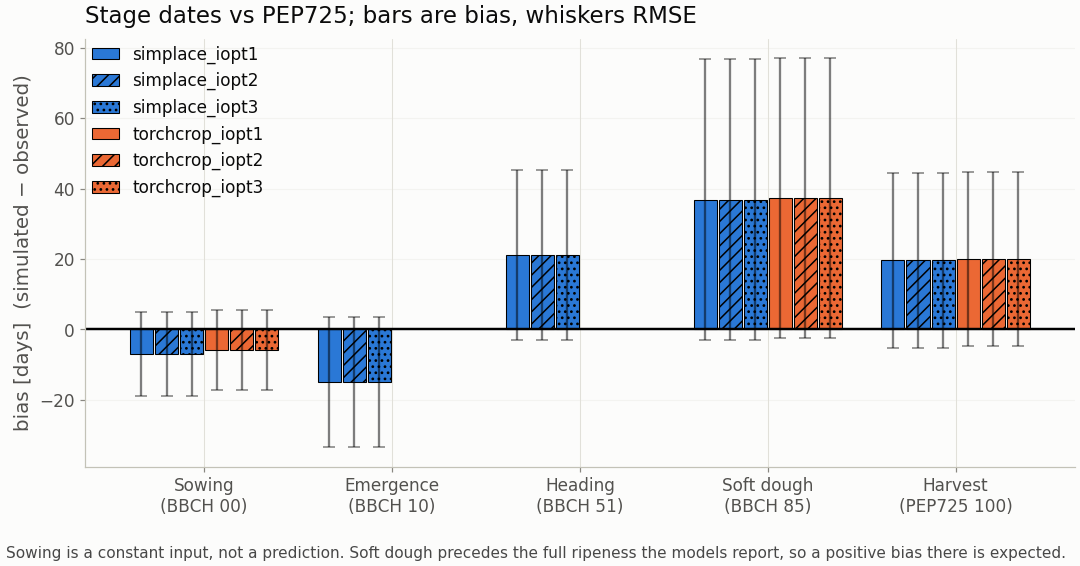

In [34]:
fig, axes = germany.plot_phenology(phenology, palette=PALETTE)
fig.savefig(config.FIGURE_DIR / "de_smoke_phenology.png", dpi=150, bbox_inches="tight")
display(fig)

## 4. Inside two seasons: 2003 and 2005

A season mean cannot say *when* a crop was short of water or nitrogen, and that
is the whole question in a drought year: `TRANRF` averaging 0.6 is a season
half-stressed throughout and a season shut down for six weeks in June, and
those are different crops. So both models are read out **daily** over two
contrasting seasons — **2003**, the European drought, and **2005**, an ordinary
year beside it.

Both series are now build artifacts read off disk, the same way the yields
above are — neither is re-derived by this notebook:

* **SIMPLACE** writes `out/daily/<id>_daily.csv` as it runs, once per swept
  IOPT (`simplace_iopt<n>/out/daily/`, its own solution build per value).
  `LAI`, `AGB_living`, `TRANRF` and `NNI` are in it only because the
  solution's `Daily_crop_growth` output declares them; a run from before that
  was added carries `LAI` alone, and `load_simplace_daily` says so rather
  than dropping the rest silently. `AGB_living` (`Biomass.sTAGBG` =
  `WLVG+WST+WSO`) is requested here instead of the solution's plain `AGB`
  (`Biomass.sTAGB` = `TAGBG+WLVD+WSTD`, i.e. living **plus** senesced leaf and
  stem litter, which is what `LintulYearly`'s `AGBiomass_t_ha` reports and
  what the yield-summary table above uses) — `sTAGB` never falls once
  senescence starts, because dead tissue stays inside the total it counts.
  The cell below relabels the loaded `AGB_living` column back to `"AGB"` so
  it plots in the same row as torchcrop's.
* **torchcrop** keeps every per-day state in memory, so `submit_cropmodelling.sh
  --smoke` / `submit_torchcrop.sh --smoke` read the summary and the daily
  trajectory off *one* simulation per swept IOPT (`run_cells_torchcrop.py
  --daily-out`, `run_cells(..., mode="both")`) rather than running the cells
  twice, and write `torchcrop/de_torchcrop_daily_iopt<1,2,3>.parquet`. These
  trajectories are therefore not just comparable to but *literally* the same
  simulations the yields above came from, on the same crop file and (in the
  chained smoke test) the same SIMPLACE-simulated sowing dates, IOPT for
  IOPT. `AGB` is `out.biomass` = `wlv+wst+wso` — also living-only, excluding
  torchcrop's own dead-leaf pool `wlvd` the same way `AGB_living` excludes
  SIMPLACE's `WLVD`/`WSTD` — converted from its native g/m² to t/ha (×0.01)
  so it lands in the same unit with nothing left for a reader to convert.

Each file's own `model` column reads `simplace`/`torchcrop` regardless of
IOPT — both are relabelled `{model}_iopt<n>` below, the same keys the summary
`runs` dict above uses, so one series stays one series across every figure in
this notebook. Rows are trimmed to the crop phase (`0 < DVS < 2`) on both
sides, so the spin-up and the frozen days past maturity never reach a plot.

In [42]:
SEASONS = [2003, 2005]
ids = cells["SimplaceID"].to_numpy()

# One frame per swept IOPT on each side, relabelled so daily_envelope's
# groupby("model") tells all six apart instead of averaging any of them
# together.
#
# AGB is requested as SIMPLACE's AGB_living (Biomass.sTAGBG = WLVG+WST+WSO)
# rather than its AGB (Biomass.sTAGB = TAGBG+WLVD+WSTD, which never falls
# because it keeps counting senesced litter) and relabelled "AGB" so it lines
# up in the same plot row as torchcrop's wlv+wst+wso -- also living-only,
# excluding its own dead-leaf pool the same way. Comparing SIMPLACE's litter-
# inclusive AGB against torchcrop's living-only one was comparing two
# different quantities, not a real model disagreement.
simplace_daily = [
    germany.load_simplace_daily(SMOKE / f"simplace_iopt{i}" / "out", ids=ids,
                                 years=SEASONS, model=f"simplace_iopt{i}",
                                 variables=("LAI", "AGB_living", "NNI", "TRANRF"))
    .replace({"variable": {"AGB_living": "AGB"}})
    for i in IOPTS
]
torchcrop_daily = []
for i in IOPTS:
    frame = pd.read_parquet(SMOKE / "torchcrop" / f"de_torchcrop_daily_iopt{i}.parquet")
    frame = frame[frame["year"].isin(SEASONS)].assign(model=f"torchcrop_iopt{i}")
    torchcrop_daily.append(frame)

daily = pd.concat([*simplace_daily, *torchcrop_daily], ignore_index=True)

print(f"{len(daily):,} rows, {daily['SimplaceID'].nunique()} cells, "
      f"{daily['variable'].nunique()} variables")

155,032 rows, 30 cells, 4 variables


In [24]:
# The season in one number per variable, so the curves below can be checked
# against something: peak canopy, and how far each stress index fell.
season = (
    daily.groupby(["variable", "year", "model"])["value"]
    .agg(mean="mean", peak="max", trough="min")
    .round(3)
    .unstack("model")
)
display(season['mean'])
season.to_csv(config.TABLE_DIR / "de_smoke_daily_2003_2005.csv")

model          simplace_iopt3  torchcrop_iopt3
variable year                                 
AGB      2003           4.640            4.905
         2005           5.566            5.688
LAI      2003           1.705            1.792
         2005           1.978            2.009
NNI      2003           0.988            0.991
         2005           0.951            0.975
TRANRF   2003           0.893            0.908
         2005           0.981            0.985

In [43]:
fig, axes = germany.plot_daily(daily, years=SEASONS, palette=PALETTE, by="season_doy")
fig.savefig(config.FIGURE_DIR / "de_smoke_daily_2003_2005.png", dpi=300,
            bbox_inches="tight")

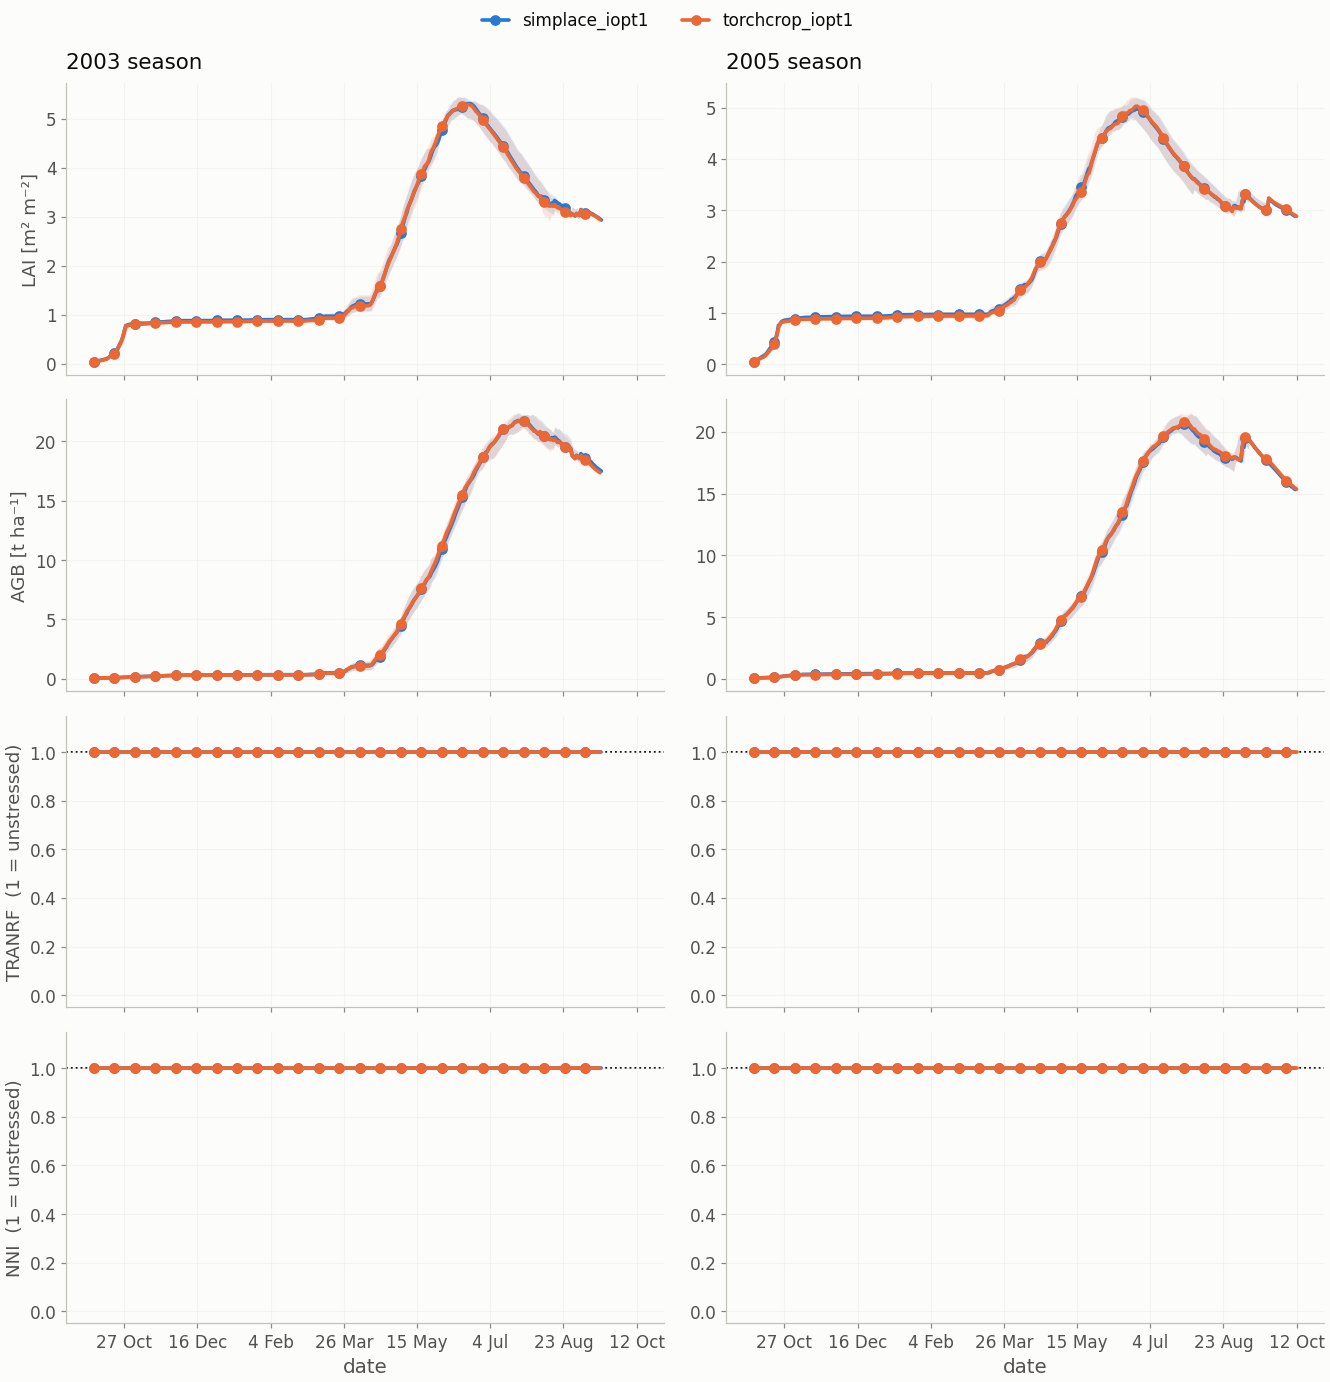

In [44]:
display(fig)

Reading the four rows:

* **LAI** is the level check. Both models should build a canopy through spring
  and lose it after anthesis; a peak that never reaches ~4-6 m² m⁻² over German
  winter wheat is a growth problem, not a timing one.
* **AGB** is the living-only pool on both sides (`AGB_living` for SIMPLACE,
  `wlv+wst+wso` for torchcrop — see §4), so a fall after peak is expected: it
  is leaf mass moving into the dead-litter pool the living total no longer
  counts, not a reported loss. It should climb through grain fill and then
  decline as the canopy senesces; a canopy gap that looks small in LAI
  compounds daily into a much larger gap here, so this row is usually the
  more legible of the two for "is one model just growing a smaller crop".
* **TRANRF** is where 2003 has to show itself. A model that responds to water
  drops here in the weeks around anthesis in 2003 and does not in 2005. A
  *chronic* offset through winter is a different thing entirely — it is
  transpiration being reduced when there is barely a canopy to transpire, which
  is a bug in the water balance, not a drought.
* **NNI** is gated on `iopt` in both models now, so the gating is a visible
  curve rather than something to take on faith on one side and assumed on the
  other: `iopt1`/`iopt2` never see a nitrogen limit (NNI pinned at 1 for
  `iopt1`; `iopt2` is water-only, so its NNI series is also flat), on
  `simplace` and `torchcrop` alike, and only the `iopt3` pair can crash
  mid-season — a fall there says the fertilizer schedule ran out, not that
  the weather was hostile. A crash on one side's `iopt3` and not the other's
  is a genuine disagreement about the same setting, not a confound with which
  IOPT each model happened to run.

The x-axis is `season_doy` — the actual calendar day-of-year, continuous
across the New Year a winter-wheat season straddles (see
`germany.add_season_doy`), not `das` (days after each model's own sowing).
That reads a stress episode against the calendar itself, which is what makes
"2003 has to show itself" in TRANRF a legible claim. It is only meaningful
because torchcrop is now latched to SIMPLACE's own *realized* sowing date
(`sowing_from_simplace.csv`, one day later than the rule's raw trigger day —
see `collect.sowing_table`'s docstring for the one-day latch this corrects
for) rather than to the export's proposed date: the two models' sowing days
now agree to within a day almost everywhere, so overlaying them on the
calendar no longer smears a timing disagreement into an apparent level one.
Pass `by="das"` to `germany.plot_daily` instead to go back to each model's own
count from its own sowing day. The band is the interquartile range **across
the 30 cells**, not an uncertainty: cells from the Rhine to Mecklenburg do not
share a season, and one model's band being far wider than the other's is
itself a result. The three series on each side share cells and seasons (and,
for torchcrop, the same crop file) and differ only in `iopt`, so any spread
within one side **is** the nutrient-limitation effect rather than a confound
with something else.

## 5. Reading it

A short checklist, because the two references fail in different directions:

* **Yield level** is the weakest claim here — a regional statistic against one
  cell, on two different moisture bases. Treat a bias inside ~1 t/ha as
  "unbiased at national level" and nothing finer.
* **Interannual `r`** is the stronger claim: it needs no moisture correction and
  no area weighting, since both sides vary about their own mean. A run with a
  fixed sowing date, one CO₂ value and no cultivar calibration should not be
  expected to manage much above ~0.4.
* **A drought year is the useful single test.** 2003 is the one in this window;
  a model that misses it is not responding to water at all.
* **Heading and harvest bias** are the cleanest results the smoke test
  produces. If either drifts by more than ~2 weeks after a change to the
  export, the change is the first suspect.